### Overview

Plotting of:
- Global gene expression KDE curves
- Gene-level KDE curves ordered by p-values (SCAN-B HiSeq training set vs TCGA-BRCA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, ks_2samp
from sklearn.preprocessing import StandardScaler
from pydeseq2.preprocessing import deseq2_norm_fit, deseq2_norm_transform
from sklearn.decomposition import PCA
import random

#### 1. Import and prepare raw count datasets

In [2]:
# import PAM50 genes
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [3]:
# import raw count files
train = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_raw_counts_subtype_train_80.csv", 
                          header=0, index_col=0)
scanb_hiseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_raw_counts_subtype_test_20.csv", 
                          header=0, index_col=0)
scanb_nextseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_cleaned_data/pam50genes_raw_counts_subtype_scanb_nextseq.csv", 
                          header=0, index_col=0)
tcga_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/pam50genes_raw_counts_subtype_tcga_brca.csv", 
                       header=0, index_col=0)

In [4]:
# check dimension
print(train.shape)
print(scanb_hiseq_test.shape)
print(scanb_nextseq_test.shape)
print(tcga_test.shape)

(2204, 52)
(551, 52)
(276, 51)
(1031, 51)


In [5]:
# check whether the first 50 column names (PAM50 gene ensembl IDs) match
print(train.columns[0:50].equals(scanb_hiseq_test.columns[0:50]))
print(train.columns[0:50].equals(scanb_nextseq_test.columns[0:50]))
print(train.columns[0:50].equals(tcga_test.columns[0:50]))

True
True
True


In [6]:
# check whether the ensemble id column order match with that of in the pam50 df
train.columns[0:50].tolist() == pam50['ensembl_gene_id'].tolist()

True

In [7]:
# extract counts
train_counts = train.iloc[:, 0:50]
scanb_hiseq_test_counts = scanb_hiseq_test.iloc[:, 0:50]
scanb_nextseq_test_counts = scanb_nextseq_test.iloc[:, 0:50]
tcga_test_counts = tcga_test.iloc[:, 0:50]

In [8]:
# rename columns
train_counts.columns = pam50['new_gene_symbol'].tolist()
scanb_hiseq_test_counts.columns = pam50['new_gene_symbol'].tolist()
scanb_nextseq_test_counts.columns = pam50['new_gene_symbol'].tolist()
tcga_test_counts.columns = pam50['new_gene_symbol'].tolist()

In [9]:
# check sum of counts in each sample
print(train_counts.iloc[0:5,:].sum(axis=1))
print(scanb_hiseq_test_counts.iloc[0:5,:].sum(axis=1))
print(scanb_nextseq_test_counts.iloc[0:5,:].sum(axis=1))
print(tcga_test_counts.iloc[0:5,:].sum(axis=1))

S006081    269320
S000392    174971
S003701    141475
S000443    260418
S003272    445648
dtype: int64
S003303    112956
S005361    171751
S000791    419519
S000201    106671
S006689     68677
dtype: int64
S000008    101140
S000019     77140
S000028    214385
S000032     66288
S000047     75254
dtype: int64
TCGA-D8-A146-01A-31R-A115-07    550783
TCGA-AQ-A0Y5-01A-11R-A14M-07    601943
TCGA-C8-A274-01A-11R-A16F-07    517185
TCGA-BH-A0BD-01A-11R-A034-07    414431
TCGA-B6-A1KC-01B-11R-A157-07    366114
dtype: int64


#### 2. Normalize raw counts using cross-sample normalization pipeline
##### PyDESeq'2 median of ratios --> Log2 transformation --> Z-score standardization

In [10]:
# deseq normalize the train set
logMeans_train, filteredGenes_train = deseq2_norm_fit(train_counts)
train_deseq2 = deseq2_norm_transform(train_counts, logMeans_train, filteredGenes_train)[0]
train_deseq2.shape

(2204, 50)

In [11]:
# deseq normalize the test sets using the train set's normalization factors
scanb_hiseq_test_deseq2 = deseq2_norm_transform(scanb_hiseq_test_counts, logMeans_train, filteredGenes_train)[0]
scanb_nextseq_test_deseq2 = deseq2_norm_transform(scanb_nextseq_test_counts, logMeans_train, filteredGenes_train)[0]
tcga_test_deseq2 = deseq2_norm_transform(tcga_test_counts, logMeans_train, filteredGenes_train)[0]

print(scanb_hiseq_test_deseq2.shape)
print(scanb_nextseq_test_deseq2.shape)
print(tcga_test_deseq2.shape)

(551, 50)
(276, 50)
(1031, 50)


In [12]:
# log2 transform the counts
train_log2 = np.log2(train_deseq2 + 1)
scanb_hiseq_test_log2 = np.log2(scanb_hiseq_test_deseq2 + 1)
scanb_nextseq_test_log2 = np.log2(scanb_nextseq_test_deseq2 + 1)
tcga_test_log2 = np.log2(tcga_test_deseq2 + 1)

In [13]:
# standardize the log2 transformed counts of the scanb hiseq training set
scaler = StandardScaler()
train_standardized = scaler.fit_transform(train_log2)
train_standardized = pd.DataFrame(train_standardized, index=train_log2.index, columns=train_log2.columns)
train_standardized.shape

(2204, 50)

In [14]:
# standardize the log2 transformed counts of the test sets using the train set-fitted scaler
scanb_hiseq_test_standardized = scaler.transform(scanb_hiseq_test_log2)
scanb_nextseq_test_standardized = scaler.transform(scanb_nextseq_test_log2)
tcga_test_standardized = scaler.transform(tcga_test_log2)

scanb_hiseq_test_standardized = pd.DataFrame(scanb_hiseq_test_standardized, index=scanb_hiseq_test_log2.index, columns=scanb_hiseq_test_log2.columns)
scanb_nextseq_test_standardized = pd.DataFrame(scanb_nextseq_test_standardized, index=scanb_nextseq_test_log2.index, columns=scanb_nextseq_test_log2.columns)
tcga_test_standardized = pd.DataFrame(tcga_test_standardized, index=tcga_test_log2.index, columns=tcga_test_log2.columns)

#### 3. Prepare the normalized raw count datasets for visualization

In [15]:
# merge standardized counts with subtypes
train_standardized_subtype_dataset = train_standardized.join(train.loc[:, ['subtype']])
scanb_hiseq_test_standardized_subtype_dataset = scanb_hiseq_test_standardized.join(scanb_hiseq_test.loc[:, ['subtype']])
scanb_nextseq_test_standardized_subtype_dataset = scanb_nextseq_test_standardized.join(scanb_nextseq_test.loc[:, ['subtype']])
tcga_test_standardized_subtype_dataset = tcga_test_standardized.join(tcga_test.loc[:, ['subtype']])

In [16]:
# add dataset column to standardized subtype dataset
train_standardized_subtype_dataset['dataset'] = 'SCAN-B HiSeq Train'
scanb_hiseq_test_standardized_subtype_dataset['dataset'] = 'SCAN-B HiSeq Test'
scanb_nextseq_test_standardized_subtype_dataset['dataset'] = 'SCAN-B NextSeq Test'
tcga_test_standardized_subtype_dataset['dataset'] = 'TCGA-BRCA Test'

In [17]:
# merge the standardized datasets
merged_standardized_subtype_dataset = pd.concat([train_standardized_subtype_dataset, scanb_hiseq_test_standardized_subtype_dataset, 
                                    scanb_nextseq_test_standardized_subtype_dataset, tcga_test_standardized_subtype_dataset],
                                   axis=0)

In [18]:
# replace Her2 by HER2
merged_standardized_subtype_dataset['subtype'] = merged_standardized_subtype_dataset['subtype'].replace({'Her2': 'HER2'})

In [19]:
# extract gene columns
gene_columns = merged_standardized_subtype_dataset.columns[:-2]

# reshape from wide to long format
merged_standardized_subtype_dataset_long = merged_standardized_subtype_dataset.melt(id_vars=['subtype', 'dataset'], value_vars=gene_columns, var_name='gene', value_name='std_counts')

#### 4. Visualize global normalized count distribution (all genes pooled) using KDE across all datasets

In [20]:
# ks test for global z-score distribution between training and test sets 

statistic_hiseq_zscore, p_value_hiseq_zscore = ks_2samp(train_standardized.iloc[:,:].values.flatten(), 
                                          scanb_hiseq_test_standardized.iloc[:,:].values.flatten())
statistic_nextseq_zscore, p_value_nextseq_zscore = ks_2samp(train_standardized.iloc[:,:].values.flatten(), 
                                          scanb_nextseq_test_standardized.iloc[:,:].values.flatten())
statistic_tcga_zscore, p_value_tcga_zscore = ks_2samp(train_standardized.iloc[:,:].values.flatten(), 
                                          tcga_test_standardized.iloc[:,:].values.flatten())

print(p_value_hiseq_zscore)
print(p_value_nextseq_zscore)
print(p_value_tcga_zscore)

0.1173615688766726
0.188078747308568
2.4525540388313565e-115


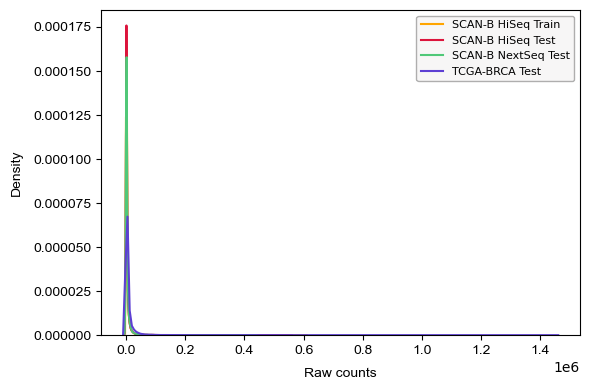

In [21]:
# KDE plots of global raw count distribution across all datasets

plt.figure(figsize=(6, 4))
sns.kdeplot(train_counts.iloc[:,:].values.flatten(), color='orange', fill=False, alpha=1, label='SCAN-B HiSeq Train')
sns.kdeplot(scanb_hiseq_test_counts.iloc[:,:].values.flatten(), color='crimson', fill=False, alpha=1, label='SCAN-B HiSeq Test')
sns.kdeplot(scanb_nextseq_test_counts.iloc[:,:].values.flatten(), color='#50C878', fill=False, alpha=1, label='SCAN-B NextSeq Test')
sns.kdeplot(tcga_test_counts.iloc[:,:].values.flatten(), color='#5D3FD3', fill=False, alpha=1, label='TCGA-BRCA Test')
# plt.title(", fontdict={'family':'Arial','color':'black','size':13, 'weight':'bold'})    
plt.xlabel('Raw counts', fontdict={'family':'Arial','color':'black','size':10}, labelpad=8)
plt.ylabel('Density', fontdict={'family':'Arial','color':'black','size':10}, labelpad=8)
plt.xticks(fontsize=10, fontfamily='Arial', color='black')
plt.yticks(fontsize=10, fontfamily='Arial', color='black')
plt.legend(loc='upper right', fontsize = 8, labelcolor='black', facecolor='#E5E4E2', edgecolor='black', framealpha=0.3)
plt.tight_layout()
# plt.savefig("kdeplot_global_gene_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

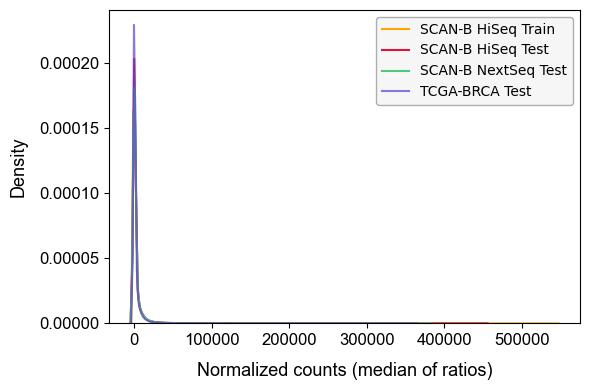

In [22]:
# KDE plots of global median of ratios normalized count distribution across all datasets

plt.figure(figsize=(6, 4))
sns.kdeplot(train_deseq2.iloc[:,:].values.flatten(), color='orange', fill=False, alpha=1, label='SCAN-B HiSeq Train')
sns.kdeplot(scanb_hiseq_test_deseq2.iloc[:,:].values.flatten(), color='crimson', fill=False, alpha=1, label='SCAN-B HiSeq Test')
sns.kdeplot(scanb_nextseq_test_deseq2.iloc[:,:].values.flatten(), color='#50C878', fill=False, alpha=1, label='SCAN-B NextSeq Test')
sns.kdeplot(tcga_test_deseq2.iloc[:,:].values.flatten(), color='#5D3FD3', fill=False, alpha=0.7, label='TCGA-BRCA Test')
# plt.title(", fontdict={'family':'Arial','color':'black','size':13, 'weight':'bold'})    
plt.xlabel('Normalized counts (median of ratios)', fontdict={'family':'Arial','color':'black','size':13}, labelpad=10)
plt.ylabel('Density', fontdict={'family':'Arial','color':'black','size':13}, labelpad=8)
plt.xticks(fontsize=12, fontfamily='Arial', color='black')
plt.yticks(fontsize=12, fontfamily='Arial', color='black')
plt.legend(loc='upper right', fontsize=10, labelcolor='black', facecolor='#E5E4E2', edgecolor='black', framealpha=0.3)
plt.tight_layout()
# plt.savefig("kdeplot_global_deseq2_normalized_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

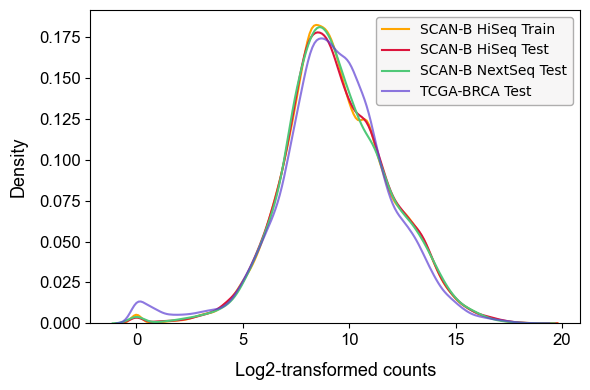

In [23]:
# KDE plots of global log2 transformed count distribution across all datasets

plt.figure(figsize=(6, 4))
sns.kdeplot(train_log2.iloc[:,:].values.flatten(), color='orange', fill=False, alpha=1, label='SCAN-B HiSeq Train')
sns.kdeplot(scanb_hiseq_test_log2.iloc[:,:].values.flatten(), color='crimson', fill=False, alpha=1, label='SCAN-B HiSeq Test')
sns.kdeplot(scanb_nextseq_test_log2.iloc[:,:].values.flatten(), color='#50C878', fill=False, alpha=1, label='SCAN-B NextSeq Test')
sns.kdeplot(tcga_test_log2.iloc[:,:].values.flatten(), color='#5D3FD3', fill=False, alpha=0.7, label='TCGA-BRCA Test')
# plt.title(", fontdict={'family':'Arial','color':'black','size':13, 'weight':'bold'})    
plt.xlabel('Log2-transformed counts', fontdict={'family':'Arial','color':'black','size':13}, labelpad=10)
plt.ylabel('Density', fontdict={'family':'Arial','color':'black','size':13}, labelpad=8)
plt.xticks(fontsize=12, fontfamily='Arial', color='black')
plt.yticks(fontsize=12, fontfamily='Arial', color='black')
plt.legend(loc='upper right', fontsize=10, labelcolor='black', facecolor='#E5E4E2', edgecolor='black', framealpha=0.3)
plt.tight_layout()
# plt.savefig("kdeplot_global_deseq2_normalized_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

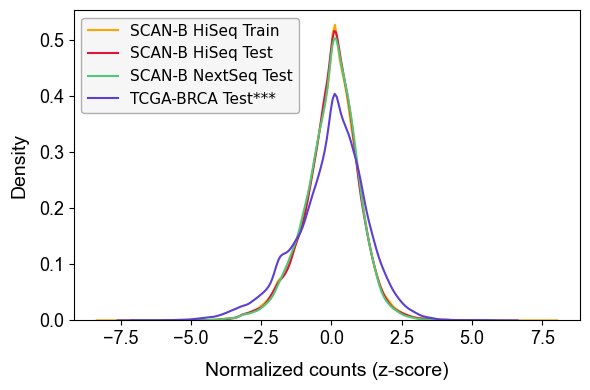

In [24]:
# KDE plots of global z-score distribution across all datasets

plt.figure(figsize=(6, 4))
sns.kdeplot(train_standardized.iloc[:,:].values.flatten(), color='orange', fill=False, alpha=1, label='SCAN-B HiSeq Train')
sns.kdeplot(scanb_hiseq_test_standardized.iloc[:,:].values.flatten(), color='crimson', fill=False, alpha=1, label='SCAN-B HiSeq Test')
sns.kdeplot(scanb_nextseq_test_standardized.iloc[:,:].values.flatten(), color='#50C878', fill=False, alpha=1, label='SCAN-B NextSeq Test')
sns.kdeplot(tcga_test_standardized.iloc[:,:].values.flatten(), color='#5D3FD3', fill=False, alpha=1, label='TCGA-BRCA Test***')
# plt.title(", fontdict={'family':'Arial','color':'black','size':13, 'weight':'bold'})    
plt.xlabel('Normalized counts (z-score)', fontdict={'family':'Arial','color':'black','size':14}, labelpad=10)
plt.ylabel('Density', fontdict={'family':'Arial','color':'black','size':14}, labelpad=8)
plt.xticks(fontsize=13, fontfamily='Arial', color='black')
plt.yticks(fontsize=13, fontfamily='Arial', color='black')
plt.legend(loc='upper left', fontsize=11, labelcolor='black', facecolor='#E5E4E2', edgecolor='black', framealpha=0.3)
plt.tight_layout()
# plt.savefig("kdeplot_global_gene_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

#### 5. Visualize gene-specific normalized count distribution using KDE across SCAN-B HiSeq training and TCGA-BRCA test sets

In [25]:
# kolmogonorov-smirnov (ks) test of z-score distribution of each gene between scanb hiseq training and tcga-brca test sets

train_tcga_pvalues = []
for i, gene in enumerate(train_standardized.columns):
    # ks test
    statistic, p_value = ks_2samp(train_standardized[gene], tcga_test_standardized[gene])
    train_tcga_pvalues.append(p_value)

df_train_tcga_pvalue = pd.DataFrame({'pam50_gene': pam50['new_gene_symbol'].tolist(), 'ks_pvalue': train_tcga_pvalues})
df_train_tcga_pvalue_sorted = df_train_tcga_pvalue.sort_values(by=['ks_pvalue'], ignore_index=True)

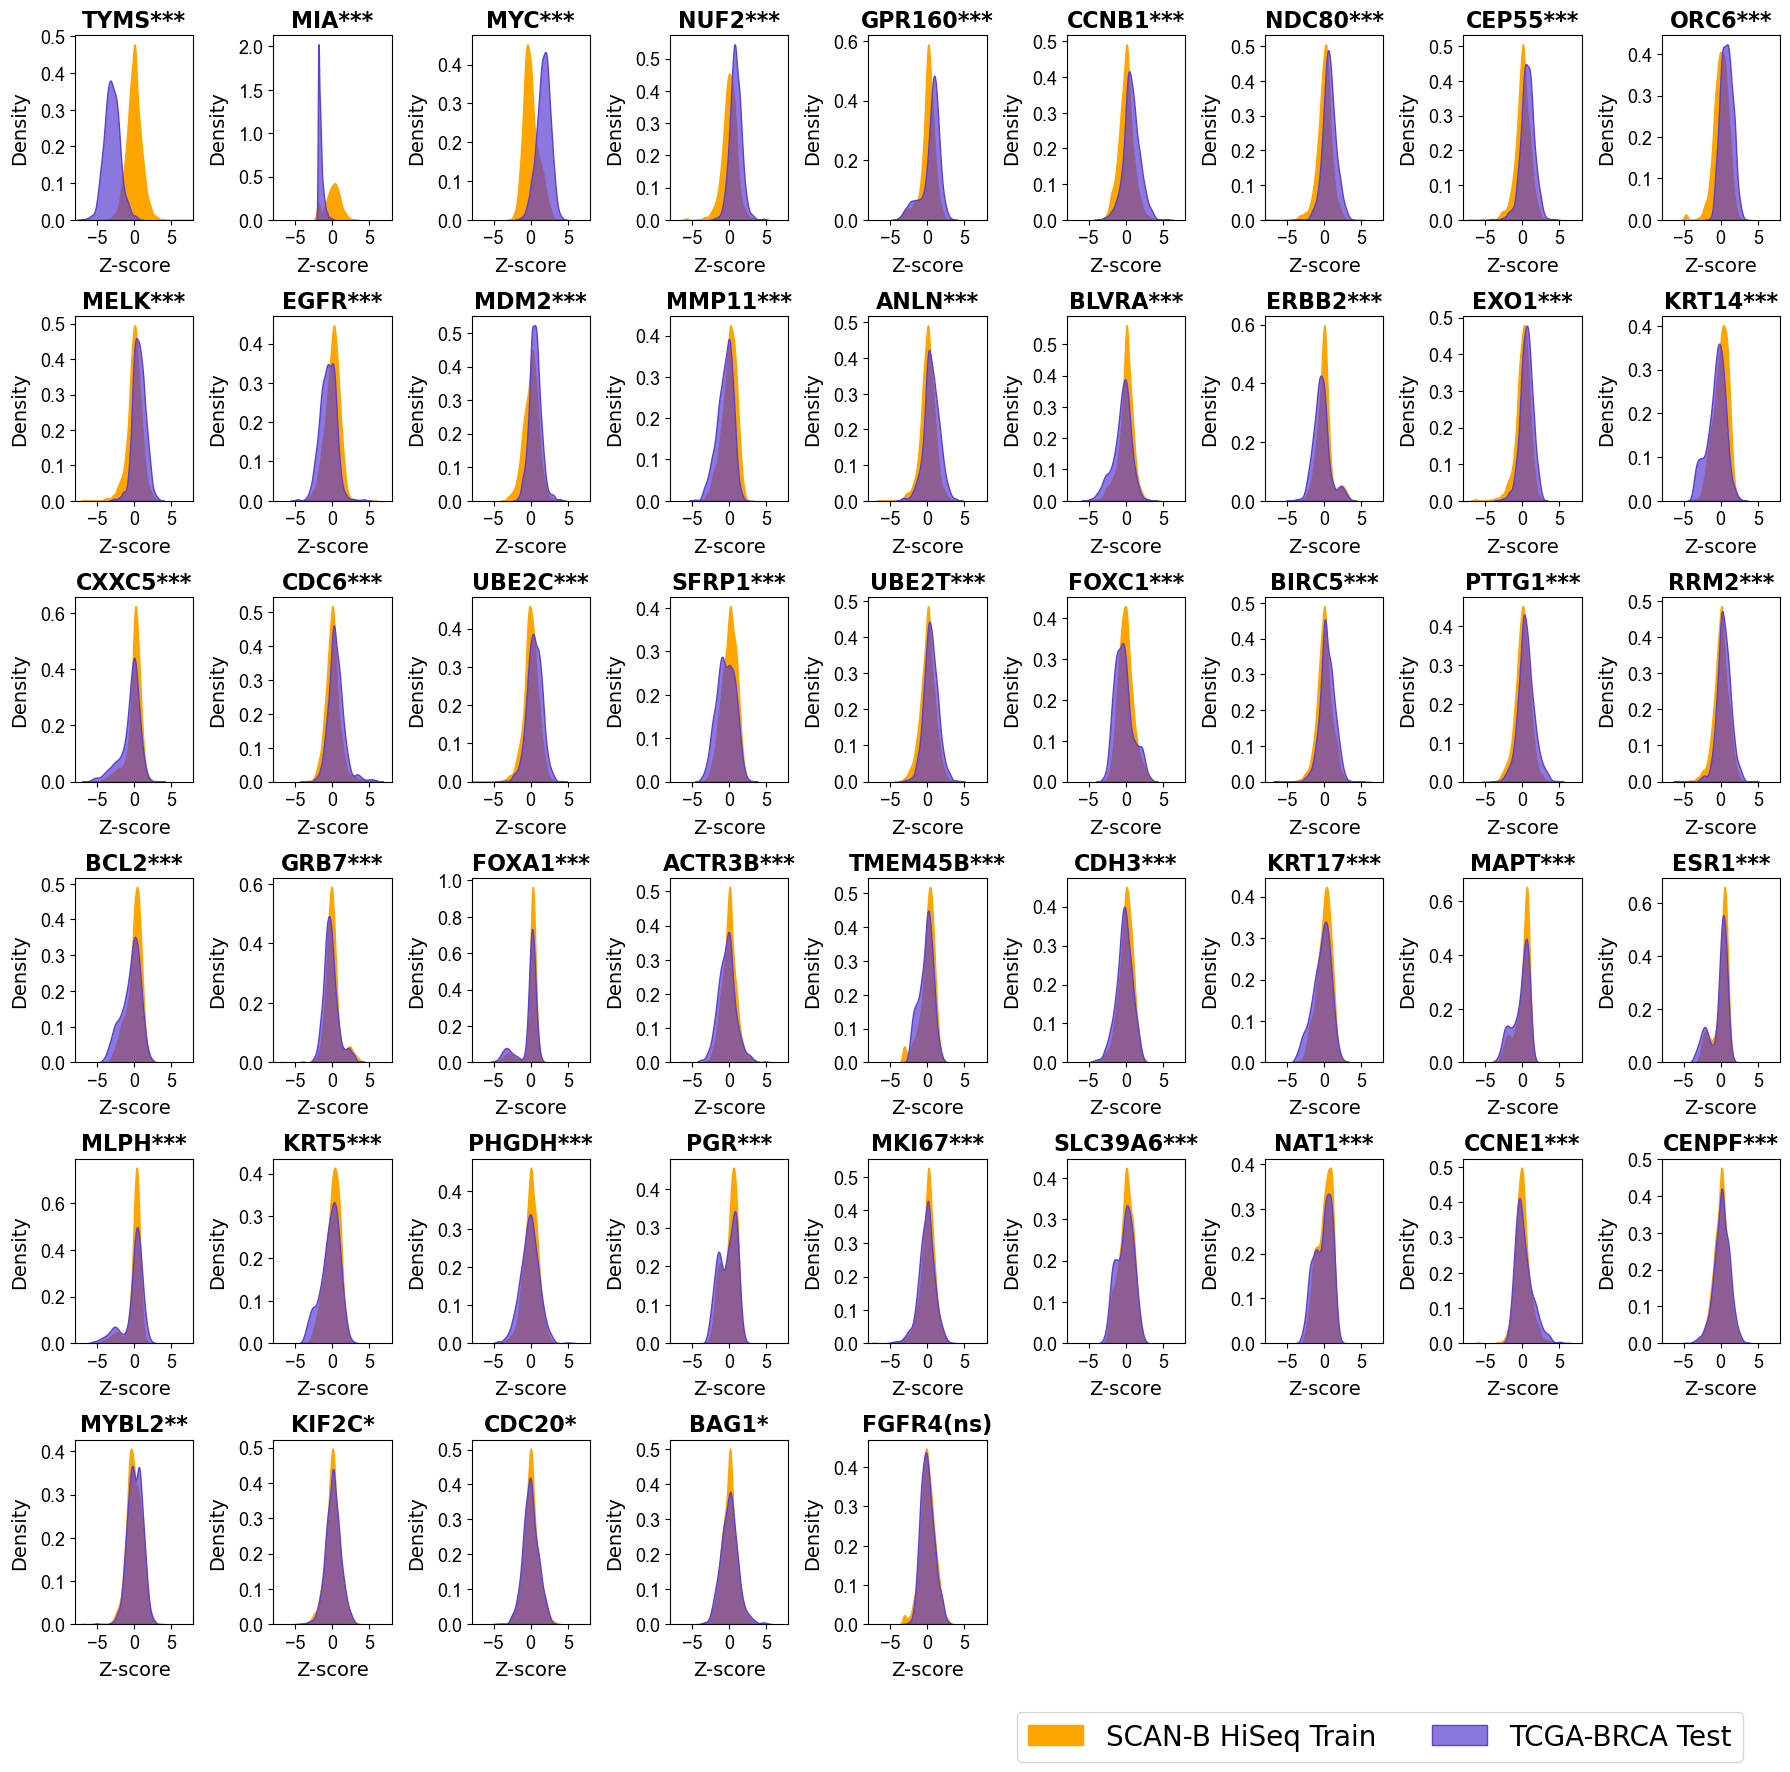

In [53]:
plt.figure(figsize=(18, 17))

for i, gene in enumerate(df_train_tcga_pvalue_sorted['pam50_gene']):
    plt.subplot(6, 9, i+1)  
    sns.kdeplot(train_standardized[gene], color='orange', fill=True, alpha=1, label='SCAN-B HiSeq Train')
    # sns.kdeplot(scanb_hiseq_test_standardized[gene], color='crimson', fill=False, alpha=1, label='SCAN-B HiSeq Test Set')
    # sns.kdeplot(scanb_nextseq_test_standardized[gene], color='#50C878', fill=False, alpha=1, label='SCAN-B NextSeq Test Set')
    sns.kdeplot(tcga_test_standardized[gene], color='#5D3FD3', fill=True, alpha=0.7, label='TCGA-BRCA Test')

    # kolmogorov-smirnov (ks) test
    statistic, p_value = ks_2samp(train_standardized[gene], tcga_test_standardized[gene])

    if p_value < 0.001:
        plt.title(f"{gene}***", fontdict={'family':'sans-serif','color':'black','size':16, 'weight':'bold'})
    elif p_value < 0.01:
        plt.title(f"{gene}**", fontdict={'family':'sans-serif','color':'black','size':16, 'weight':'bold'})
    elif p_value < 0.05:
        plt.title(f"{gene}*", fontdict={'family':'sans-serif','color':'black','size':16, 'weight':'bold'})
    elif p_value >= 0.05:
        plt.title(f"{gene}(ns)", fontdict={'family':'sans-serif','color':'black','size':16, 'weight':'bold'})
    
    plt.xlabel('Z-score', fontdict={'family':'sans-serif','color':'black','size':14}, labelpad=6)
    plt.ylabel('Density', fontdict={'family':'sans-serif','color':'black','size':14}, labelpad=8)
    plt.xlim(-8,8)
    plt.xticks(fontsize=13, fontfamily='Arial', color='black')
    plt.yticks(fontsize=13, fontfamily='Arial', color='black')
    
plt.tight_layout()
plt.legend(bbox_to_anchor=(7.5, -0.4), ncol=2, fontsize = 20)
plt.savefig("kdeplot_gene_level_journal_vers.png", dpi=300, bbox_inches='tight')
plt.show()